# CG3201 Project 4: Image Captioning with CNN-RNN Architectures - Global Context vs. Attention
By Kenneth Wong Cun Wi A0303203A

## Project Summary
In this project, we investigate how different ways of bridging visual features to a language decoder affect learning behaviour and caption quality on a 2,000-image subset of Flickr8k.
We implement a main model class that swaps between two variants, using the same CNN encoder, embedding layer, LSTM cell and FC head, but differ in how visual context is injected into the decoder:

- **Model A - Global Context Baseline.** A single static context vector $\mathbf{v}$ from the globally-pooled ResNet-50 feature is fed to the LSTM at every time step (*This is the one-to-many captioning that we learnt from lecture 7 slides 24-30*).
- **Model B - Spatial Attention.** Using an Attention block/layer, a dynamic context vector $\mathbf{u}_t$ is computed at every time step via scaled dot-product attention over the $7\times 7=49$ spatial positions of the ResNet-50 grid feature (*This is the image captioning using RNN and attention layer with scaled dot product from slides 16-25 in lecture 8).

The models are evaluated through plotting of loss curves, performance metrics such as corpus-level BLEU score using the test set, training time and number of learnable parameters, and qualitative examples with heatmaps.

## Project Enhancements
There were various adjustments and fixes along the way, after observing the results from each training and validation session (e.g. heatmaps are localised at the same point, severe overfitting, captions are repetitive and inaccurate). These are documented below under Part 3 which is where analysis is done.

# Part 1: Data Loading and Preprocessing

The `adityajn105/flickr8k` dataset contains 8,091 images with 5 captions each stored in `captions.txt` file. Using `random.sample(image_list, 2000)` seeded by `SEED=203`, we randomly choose a subset of it and then split into (1,600, 200, 200) training/validation/test images.

### Image Preprocessing
As we use a pre-trained ResNet-50 encoderevery image is resized, centre-cropped, converted to a tensor and normalised with the standard ImageNet statistics so its distribution matches what ResNet-50 was trained on:
1. `Resize(256)`
2. `CenterCrop(224)`
3. `ToTensor()`
4. `Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])`

### Text Preprocessing
For the captions we follow the classic one-to-many captioning recipe of *Lecture 7, slides 24-28* (vocabulary = two lookup tables `word2idx`/`idx2word`; Embedding layer for dense representation):
1. *Normalisation*: lowercase and remove all non-alphanumeric characters.
2. *Framing*: prepend `<start>` and append `<end>` to every sequence.
3. *Vocabulary construction* : built only from the training split, with `min_freq=5` and include special tokens `<pad>, <start>, <end>, <unk>` 
4. *Tokenization & Padding*: unknown words in val/test are mapped to `<unk>` and every sequence is padded to the length of the longest training sequence with `<pad>` so that they can be stacked into uniform batches.


In [ ]:
# Imports & dependencies
import os, re, time, random                            # standard-library utilities
from collections import Counter, defaultdict           # counter for vocab frequency; defaultdict for caption grouping

import numpy as np                                     # numerical arrays
import pandas as pd                                    # tabular display of metrics
import matplotlib.pyplot as plt                        # plotting loss curves & heatmaps

from PIL import Image                                  # image loading
import torch                                           # core deep-learning framework
import torch.nn as nn                                  # nn.Module, nn.LSTMCell, nn.Embedding, nn.Linear
import torch.nn.functional as F                        # softmax for attention
from torch.utils.data import Dataset, DataLoader       # custom dataset + batching
from torchvision import transforms                     # image transforms pipeline
from torchvision.models import resnet50, ResNet50_Weights  # pretrained ResNet-50 encoder

SEED = 203                                             # last 3 student id digits
random.seed(SEED)                                      # seeds Python's random module (used for random.sample)
np.random.seed(SEED)                                   # seeds NumPy
torch.manual_seed(SEED)                                # seeds PyTorch CPU RNG
if torch.cuda.is_available():                          # also seed GPU RNGs if CUDA is available
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True          # deterministic cuDNN kernels (slower but reproducible)
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # use GPU if available
print("Using device:", device)


Using device: cuda


In [ ]:
# Dataset Acquisition

root = "/kaggle/input/datasets/adityajn105/flickr8k"
assert root is not None, "Could not find Flickr8k dataset"

IMG_DIR  = os.path.join(root, "Images")                           # folder containing all images
CAP_FILE = os.path.join(root, "captions.txt")                     # CSV: image, caption
print("Dataset root:", root)

# Load captions.txt into a dict: image_name -> list of 5 captions
caps_df = pd.read_csv(CAP_FILE)
image_to_caps = defaultdict(list)                                 # {img_name: [cap1,...,cap5]}
for _, row in caps_df.iterrows():                                 # iterate over all rows
    image_to_caps[row["image"]].append(row["caption"])            # group captions by image

# Check rows and keep only images with exactly 5 captions
image_list = sorted([img for img, caps in image_to_caps.items() if len(caps) == 5])
print(f"Total usable images (with 5 captions): {len(image_list)}")


Dataset root: /kaggle/input/datasets/adityajn105/flickr8k
Total usable images (with 5 captions): 8091


In [ ]:
# Random Subset Selection
random.seed(SEED)                                                 # re-seed right before sampling for safety
subset_imgs = random.sample(image_list, 2000)

# Split into 1600 / 200 / 200 (with shuffle to randomise split)
random.seed(SEED)
random.shuffle(subset_imgs)
train_imgs = subset_imgs[:1600]                                   # first 1,600 images -> training
val_imgs   = subset_imgs[1600:1800]                               # next 200 -> validation
test_imgs  = subset_imgs[1800:2000]                               # last 200 -> test
print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")


Train: 1600 | Val: 200 | Test: 200


In [ ]:
# Image Preprocessing

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

image_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),                                    # HxWxC uint8 [0,255] -> CxHxW float [0,1]
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),        # (x - mu) / sigma normalisation
])


In [ ]:
# Text normalisation & tokenisation helpers
#       vocabulary = two lookup tables (word2idx, idx2word), slide 25 of lecture 7
#       with special tokens <pad>, <start>, <end>, <unk>, which is the <SOS> and <EOS> eqv

PAD_TOK, START_TOK, END_TOK, UNK_TOK = "<pad>", "<start>", "<end>", "<unk>"
SPECIALS = [PAD_TOK, START_TOK, END_TOK, UNK_TOK]

# replace every non-alphanumeric / non-whitespace character with a space.
_non_alnum_re = re.compile(r"[^a-z0-9\s]")

def normalize_caption(cap: str) -> list:
    """Lowercase + remove punctuation, then split on whitespace -> list of tokens.
    Example: 'A dog, running!' -> ['a','dog','running']"""
    cap = cap.lower()                                             # 1. lowercase everything
    cap = _non_alnum_re.sub(" ", cap)                             # 2. strip non-alphanumeric chars
    tokens = cap.split()                                          # 3. whitespace split
    return tokens

def frame_caption(tokens: list) -> list:
    """Framing a sequence by prepending <start> and appending <end>."""
    return [START_TOK] + tokens + [END_TOK]

def encode_caption(cap: str) -> list:
    """Normalise -> frame -> map each token to its index (Out of Vocab (OOV) -> <unk>)."""
    toks = frame_caption(normalize_caption(cap))
    unk = word2idx[UNK_TOK]
    return [word2idx.get(tok, unk) for tok in toks]               # OOV -> <unk>

# ------ Text normalisation & tokenisation starts here ------

# Filter by count
MIN_FREQ = 5                                                      # exclude words with count < 5
word_counter = Counter()
for img in train_imgs:                                            # only training images
    for cap in image_to_caps[img]:                                # each image has 5 captions
        word_counter.update(normalize_caption(cap))               # count normalised tokens

# word2idx starts with specials at fixed indices 0..3
word2idx = {tok: i for i, tok in enumerate(SPECIALS)}
for word, cnt in sorted(word_counter.items(), key=lambda x: (-x[1], x[0])):  # sort by freq desc, word asc
    if cnt >= MIN_FREQ and word not in word2idx:
        word2idx[word] = len(word2idx)                            # assign next index
idx2word = {i: w for w, i in word2idx.items()}                    # inverse lookup
VOCAB_SIZE = len(word2idx)
print(f"Vocabulary size (with specials, min_freq={MIN_FREQ}): {VOCAB_SIZE}")

# Compute max length from the training set only
max_len = 0
for img in train_imgs:
    for cap in image_to_caps[img]:
        max_len = max(max_len, len(encode_caption(cap)))          # longest training sequence
print(f"Max caption length (train, incl. <start>/<end>): {max_len}")

def pad_sequence(seq, length, pad_idx=word2idx[PAD_TOK]):
    """Pad with <pad> on the right up to `length`; truncate if longer."""
    seq = seq[:length]                                            # truncate if longer than max_len
    return seq + [pad_idx] * (length - len(seq))                  # right-pad with <pad>

Vocabulary size (with specials, min_freq=5): 1247
Max caption length (train, incl. <start>/<end>): 35


In [ ]:
# Custom Dataset wrapping (image -> features, caption -> ids)
class Flickr8kCaptionDataset(Dataset):
    """Returns (image_tensor, caption_ids_tensor, length) for one (image, caption) pair.
    Because each image has 5 captions, we flatten so the dataset has 5x more items than images.
    This lets the DataLoader shuffle over all (image, caption) pairs each epoch."""
    def __init__(self, image_names, image_to_caps, img_dir, transform, max_len):
        self.pairs = []                                           # list of (image_name, single_caption)
        for img in image_names:
            for cap in image_to_caps[img]:
                self.pairs.append((img, cap))                     # one row per (image, caption)
        self.img_dir = img_dir                                    # path to Images
        self.transform = transform                                # image pipeline (Resize/Crop/Tensor/Normalize)
        self.max_len = max_len                                    # fixed padding length

    def __len__(self):
        return len(self.pairs)                                    # number of (img, cap) pairs

    def __getitem__(self, idx):
        img_name, cap = self.pairs[idx]                           # look up the pair
        # image
        img_path = os.path.join(self.img_dir, img_name)           # build full file path (Project 3 style)
        img = Image.open(img_path).convert("RGB")                 # load + ensure 3-channel
        img = self.transform(img)                                 # (3,224,224) normalised tensor
        # caption
        ids = encode_caption(cap)                                 # list of encoded tokens in ints incl. <start>/<end>
        ids = pad_sequence(ids, self.max_len)                     # pad/truncate to max_len
        return img, torch.tensor(ids, dtype=torch.long)

BATCH_SIZE = 32                                                   # balance GPU memory as ResNet-50 inference is heavy

# DataLoader config
DATALOADER_MODE = "balanced"                                      # or "max_stability": num_workers=0. Safest

if DATALOADER_MODE == "balanced":
    # persistent_workers=True keeps the worker processes alive between epochs.
    # This avoids the error "AssertionError: can only test a child process" spam that appears
    # when __del__ tries to shut down workers from the wrong parent PID during Jupyter GC
    loader_kwargs = dict(
        num_workers=2,
        pin_memory=True,
        persistent_workers=True,                                  # reuse workers across epochs
        prefetch_factor=2,                                        # how many batches each worker pre-loads
    )
else: 
    # Single-process loading: slowest, but zero chance of worker-teardown issues.
    loader_kwargs = dict(num_workers=0, pin_memory=True)

train_ds = Flickr8kCaptionDataset(train_imgs, image_to_caps, IMG_DIR, image_transform, max_len)
val_ds   = Flickr8kCaptionDataset(val_imgs,   image_to_caps, IMG_DIR, image_transform, max_len)
test_ds  = Flickr8kCaptionDataset(test_imgs,  image_to_caps, IMG_DIR, image_transform, max_len)

# For PyTorch batching, shuffling, parallel loading and iteration during epochs
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print(f"Pairs  -> train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}  "
      f"(DataLoader mode: {DATALOADER_MODE})")


Pairs  -> train: 8000 | val: 1000 | test: 1000  (DataLoader mode: balanced)


In [ ]:
# Visual sanity check: 3 random images (raw + processed) + 5 preprocessed captions each

random.seed(SEED)
sample_imgs = random.sample(train_imgs, 3)                        # three training images

# Channel-wise mean/std tensors shaped (3,1,1) to broadcast over the (3,224,224) image tensor
mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))                  # 2 rows (raw / processed) x 3 cols
for col, img_name in enumerate(sample_imgs):
    img_path = os.path.join(IMG_DIR, img_name)
    raw = Image.open(img_path).convert("RGB")

    # Top row: raw image
    axes[0, col].imshow(raw)
    axes[0, col].axis("off")
    axes[0, col].set_title(f"Raw: {img_name}\nsize = {raw.size[0]}x{raw.size[1]}", fontsize=9)

    # Bottom row: post-transform image (what actually feeds ResNet-50)
    processed = image_transform(raw)                              # (3, 224, 224) normalised tensor
    denorm    = (processed * std_t + mean_t).clamp(0, 1)          # un-normalise back into [0,1] for display
    denorm_np = denorm.permute(1, 2, 0).numpy()                   # CxHxW -> HxWxC for imshow
    axes[1, col].imshow(denorm_np)
    axes[1, col].axis("off")
    axes[1, col].set_title(
        "Processed: Resize(256) -> CenterCrop(224)\n-> ToTensor -> Normalize(ImageNet)",
        fontsize=9,
    )

    # Print numeric stats on the normalised tensor
    t = processed
    print(f"\n=== {img_name} ===")
    print(f"  processed tensor shape={tuple(t.shape)}  "
          f"min={t.min():.3f}  max={t.max():.3f}  mean={t.mean():.3f}")

    # Show the 5 fully preprocessed & tokenized captions for this image
    for i, cap in enumerate(image_to_caps[img_name]):
        ids    = encode_caption(cap)                              # list of int ids (incl. <start>/<end>)
        tokens = [idx2word[i] for i in ids]                       # decode back to tokens for readability
        print(f"  Caption {i+1}:")
        print(f"    raw        : {cap}")
        print(f"    tokens     : {tokens}")
        print(f"    token ids  : {ids}")

plt.tight_layout()
plt.show()


# Part 2: Architectural Implementation

## Feature Extraction Strategy

**I choose to *freeze* the ResNet-50 encoder, and apply this choice consistently to both Model A and Model B** (as the spec requires for a fair comparison). Four reasons motivate this choice, in descending order of importance:

1. **Data scale.** We have 1,600 training images. Fine-tuning ResNet-50 exposes ~23M pretrained convolutional weights to that tiny set - overwhelmingly likely to destroy the ImageNet representations through overfitting before gaining any Flickr8k-specific benefit. Classical captioning work (Vinyals et al. *Show and Tell*, Xu et al. *Show, Attend and Tell* - our *Lecture 8 slides 16-21* reference) freezes the CNN for exactly this reason on small datasets.
2. **Fair A-vs-B comparison.** The spec requires the same choice for both variants. Freezing gives the cleanest controlled experiment - the only moving parts are the bridge + decoder, so any A/B difference is definitively attributable to the context-formulation mechanism, not to two differently-adapted encoders.
3. **Bottleneck location.** Our qualitative errors (observed in the runs below) are decoder-side (repetition, wrong colours, wrong gender), not encoder-side - the model clearly recognises categories (hats, dogs, people, playground equipment) using the ImageNet features. Fine-tuning the encoder wouldn't fix a greedy-decoder repetition loop.
4. **Compute.** Fine-tuning adds ~23M parameters to every backward pass - roughly an order of magnitude more gradient computation per step on a T4/3060 Ti-class GPU. Given (1) and (2), this cost would not be justified.

## Macro Architecture

The overall blueprint is identical for both variants (drawn from *Lecture 7 slides 24-29* for the one-to-many decoder with embedding + softmax head, and *Lecture 8 slides 16-21* for spatial grid features):

```
Image(3x224x224) -> ResNet-50 (stem + stages 1-4) -> Grid:(B,2048,7,7)
                                                  -> GAP:(B,2048)
                                                  |
                         +------------------------+------------------------+
                         |                        |                        |
                 Shared init proj        Model A context proj      Model B spatial proj
                 GAP -> (h0, c0)           GAP -> v in R^256        permute+Linear -> (B,49,256)
                 each in R^256
                         |                        |                        |
                         +----> LSTMCell-256 (input = concat[embed_t, ctx_t])
                                                  |
                                               FC (256 -> vocab)  -> softmax
```

### Bridge (Dimensionality Alignment)
- **Shared** `init_h`, `init_c`: `Linear(2048, 256)` on the GAP vector -> initial $\mathbf{h}_0,\mathbf{c}_0$ for the LSTM.
- **Model A context proj** `ctx_proj`: `Linear(2048, 256)` on GAP -> static $\mathbf{v}\in\mathbb{R}^{256}$ (fed at every step).
- **Model B spatial proj** `spatial_proj`: grid is permuted from $(B,2048,7,7)\to(B,49,2048)$, then `Linear(2048, 256)` -> $(B,49,256)$. Model B also applies `LayerNorm(256)` to each of the 49 projected key vectors - see the Model B decoder cell for the empirical reason (prevents attention collapse; disclosed as "on top of what was taught in lecture").

### Decoder (shared LSTMCell + FC head)
- `Embedding(vocab_size, 256)` per *Lecture 7 slide 26-28*.
- `LSTMCell(input=512, hidden=256)` - input is `concat[embed_t (256), ctx_t (256)]`.
- `Dropout(0.5)` before the FC head on the hidden state (regularisation; disclosed).
- `Linear(256, vocab_size)` produces logits over the vocabulary -> softmax gives the next-word distribution (*Lecture 7 slide 29*).

### Context Formulation (the only difference between A and B)
- **Model A.** `ctx_t = v` for every `t` (a single fixed vector per image).
- **Model B.** At every step we compute a **scaled dot-product attention** (*Lecture 8 slide 24*) between the query $\mathbf{h}_{t-1}$ and the 49 projected spatial features $\mathbf{K}=\mathbf{V}\in\mathbb{R}^{49\times 256}$:

$$
\mathbf{e}_t = \frac{\mathbf{K}\,\mathbf{h}_{t-1}}{\sqrt{D}},\qquad
\boldsymbol\alpha_t = \mathrm{softmax}(\mathbf{e}_t),\qquad
\mathbf{u}_t = \boldsymbol\alpha_t^\top\mathbf{V}.
$$

The scaling by $\sqrt{D}$ (here $D=256$) is essential: without it, larger dimensions cause the softmax to saturate near 0/1 and gradients vanish (*Lecture 8 slide 25*).

### Decoding strategies
- **Training - Teacher Forcing** (*Lecture 7 slide 23*). At step $t$ we feed the **ground-truth** token $\widetilde{y}_{t-1}$, not the model's own prediction. This stabilises training.
- **Inference - Autoregressive Greedy Search** (*Lecture 7 slide 29*). Starting from `<start>`, at every step we feed back the argmax of the previous logit and stop when `<end>` is produced or a maximum length is reached. In run 3 we also add a **no-repeat 3-gram decode filter** (disclosed as a modified-greedy enhancement) - rationale and empirical justification are in the "Second Run Analysis" and "Run 3 Results" markdown cells.


In [8]:
# ---------------- CNN Encoder (pretrained ResNet-50, frozen) ----------------
# We use torchvision's ImageNet-pretrained ResNet-50 (He et al., CVPR 2016 - Lec 6 slides 47-55).
# We strip the final avgpool + FC (which map to the 1000 ImageNet classes) because we need:
#   (a) the 2048x7x7 spatial grid *and*
#   (b) the 2048-d global-average-pooled vector.

class ResNet50Encoder(nn.Module):
    """Frozen ResNet-50 that returns BOTH the 7x7 spatial grid and the GAP vector."""
    def __init__(self):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2                  # ImageNet V2 weights (76.1% top-1)
        backbone = resnet50(weights=weights)                      # full ResNet-50
        # Everything up to and including layer4 (stage 4). Drops avgpool + fc.
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        self.gap = nn.AdaptiveAvgPool2d(1)                        # global average pool -> (B,2048,1,1)

        # ---- Freeze the encoder: no gradients, no updates ----
        for p in self.backbone.parameters():                      # iterate over all ResNet params
            p.requires_grad = False                               # disable gradient computation
        self.backbone.eval()                                      # BN uses running statistics

    def train(self, mode=True):
        # Even when outer model is set to train(), keep the ResNet-50 in eval mode
        # to preserve the ImageNet BatchNorm statistics (otherwise BN would use batch stats
        # from 32 small images and distort the frozen features).
        super().train(mode)
        self.backbone.eval()
        return self

    def forward(self, images):                                    # images: (B, 3, 224, 224)
        grid = self.backbone(images)                              # (B, 2048, 7, 7) - spatial grid after stage 4
        pooled = self.gap(grid).flatten(1)                        # (B, 2048) - global average pooling
        return grid, pooled                                       # return both outputs


In [9]:
# -------- Quick shape sanity check on a random batch (feature extraction pipeline) --------
# This is the "feature extraction pipeline screenshot" for Deliverable 2.

encoder_check = ResNet50Encoder().to(device).eval()               # encoder in eval mode
with torch.no_grad():
    imgs_ck, _, _ = next(iter(train_loader))                      # first training batch
    grid_ck, gap_ck = encoder_check(imgs_ck.to(device))           # run through frozen encoder
print("Grid  feature shape:", tuple(grid_ck.shape), "-> should be (B, 2048, 7, 7)")
print("GAP   feature shape:", tuple(gap_ck.shape),  "-> should be (B, 2048)")
del encoder_check, grid_ck, gap_ck                                # free GPU memory


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s] 


Grid  feature shape: (32, 2048, 7, 7) -> should be (B, 2048, 7, 7)
GAP   feature shape: (32, 2048) -> should be (B, 2048)


In [10]:
# ---------------- Model A Decoder: Global Context (static vector at every step) ----------------
# At every time step t, the LSTM receives [embed(y_{t-1}), v], where v is a single image-level
# 256-d vector computed ONCE from the GAP feature. This is the "fixed context" baseline
# from Lecture 8 slide 5 (pre-attention Seq2Seq).
#
# ** Regularisation (on top of what was taught in lecture) **
# Our first training run showed heavy overfitting (train CE ~1.3 while val CE plateaued ~3.0)
# and mode-collapsed greedy captions ("a man in a red shirt" for every image). We add a
# Dropout(0.5) layer before the final FC head to regularise the hidden state -> vocab
# projection, following standard practice in Show-and-Tell / Show-Attend-and-Tell. Dropout is
# automatically disabled at inference by model.eval(), so it does not affect greedy decoding.

EMBED_DIM   = 256                                                 # word-embedding dim (spec: 256)
HIDDEN_DIM  = 256                                                 # LSTM hidden dim  (spec: 256)
FEATURE_DIM = 2048                                                # ResNet-50 stage-4 channel count
DROPOUT_P   = 0.5                                                 # strong regularisation (only 1,600 imgs in training set)

class GlobalContextDecoder(nn.Module):
    """Model A: single static context vector v fed at every LSTM step."""
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
                 feat_dim=FEATURE_DIM, dropout=DROPOUT_P):
        super().__init__()
        # -------------- Bridge (dimensionality alignment) --------------
        self.init_h    = nn.Linear(feat_dim, hidden_dim)          # GAP (2048) -> h0 (256)
        self.init_c    = nn.Linear(feat_dim, hidden_dim)          # GAP (2048) -> c0 (256)
        self.ctx_proj  = nn.Linear(feat_dim, hidden_dim)          # GAP (2048) -> v  (256)  <-- Model A only

        # -------------- Decoder (Embedding + LSTMCell + Dropout + FC head) --------------
        self.embedding = nn.Embedding(vocab_size, embed_dim)      # token id -> 256-d embedding (Lec7 slide 26-28)
        self.lstm_cell = nn.LSTMCell(embed_dim + hidden_dim,      # input = concat[embed, ctx]
                                     hidden_dim)                  # hidden = 256
        self.dropout   = nn.Dropout(dropout)                      # FIX: regularise hidden state before the classifier
        self.fc        = nn.Linear(hidden_dim, vocab_size)        # classification head -> vocab logits

    def init_state(self, gap):
        """Produce initial (h0, c0) from the pooled feature."""
        return torch.tanh(self.init_h(gap)), torch.tanh(self.init_c(gap))

    def forward(self, grid, gap, captions):
        """Teacher-forcing forward pass.
        grid: (B, 2048, 7, 7) - unused by Model A (kept for uniform signature)
        gap : (B, 2048)       - global average pool feature
        captions: (B, L)      - ground-truth token ids incl. <start>, <end>, <pad>
        Returns logits: (B, L, V)"""
        B, L = captions.shape
        h, c = self.init_state(gap)                               # (B,256), (B,256)
        v    = self.ctx_proj(gap)                                 # (B,256)  -- static context
        emb  = self.embedding(captions)                           # (B,L,256)
        logits = []
        for t in range(L):                                        # iterate over time steps
            x_t = emb[:, t]                                       # (B,256) teacher-forced token embedding
            ctx = v                                               # (B,256) STATIC context (same every t)
            lstm_in = torch.cat([x_t, ctx], dim=-1)               # (B, 512) -- concat embed + context
            h, c = self.lstm_cell(lstm_in, (h, c))                # LSTM step
            logits.append(self.fc(self.dropout(h)))               # dropout -> FC -> vocab logits
        return torch.stack(logits, dim=1)                         # (B, L, V)


In [11]:
# ---------------- Model B Decoder: Spatial Attention (dynamic context per step) ----------------
# At every time step t we compute a scaled dot-product attention between:
#   - Query: the *previous* hidden state h_{t-1}  (B, 256)
#   - Keys = Values: the 49 LayerNorm'd projected spatial vectors  (B, 49, 256)
# Scaling by sqrt(D) prevents softmax saturation (Lecture 8 slide 25).
#
# ** Key-feature LayerNorm (on top of what was taught in lecture) **
# The lecture defines alignment as e_i = K_i . q / sqrt(D). In practice, when K is produced
# by an unnormalised Linear layer, different positions can have very different norms and
# softmax collapses onto the single largest-norm position regardless of the query. Our first
# training run exhibited exactly this pathology: the attention heatmap was pinned to the
# SAME spatial cell for every generated word, across every image. Adding nn.LayerNorm to the
# 49 projected K vectors forces each position to comparable magnitude, so the dot product
# measures angular alignment (the interpretation we actually want for attention). The
# scoring rule itself remains scaled dot product as the spec requires.

class AttentionDecoder(nn.Module):
    """Model B: dynamic scaled dot-product attention over 49 spatial positions."""
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
                 feat_dim=FEATURE_DIM, dropout=DROPOUT_P):
        super().__init__()
        # -------------- Bridge --------------
        self.init_h       = nn.Linear(feat_dim, hidden_dim)       # GAP (2048) -> h0 (256)
        self.init_c       = nn.Linear(feat_dim, hidden_dim)       # GAP (2048) -> c0 (256)
        self.spatial_proj = nn.Linear(feat_dim, hidden_dim)       # 2048 -> 256 for each of 49 positions
        self.key_norm     = nn.LayerNorm(hidden_dim)              # FIX: LN each K vector -> fixes attention collapse

        # -------------- Decoder --------------
        self.embedding = nn.Embedding(vocab_size, embed_dim)      # shared embedding layout as Model A
        self.lstm_cell = nn.LSTMCell(embed_dim + hidden_dim,      # input = concat[embed, attn_ctx]
                                     hidden_dim)                  # hidden = 256
        self.dropout   = nn.Dropout(dropout)                      # FIX: regularise hidden state before the classifier
        self.fc        = nn.Linear(hidden_dim, vocab_size)        # vocab logits

        # cache the 1/sqrt(D) scalar for the scaled dot product
        self.scale = hidden_dim ** 0.5                            # sqrt(D_Q) from Lec 8 slide 24

    def init_state(self, gap):
        return torch.tanh(self.init_h(gap)), torch.tanh(self.init_c(gap))

    def build_keys(self, grid):
        """Build the 49-position Key/Value matrix from the spatial grid.
        Extracted so training (forward) and inference (ImageCaptioner.generate) use IDENTICAL
        K construction -- LayerNorm included. Without this, training K would be LN'd but
        inference K would not, silently breaking attention at test time."""
        K_raw = grid.flatten(2).transpose(1, 2)                   # (B, 49, 2048)
        K     = self.spatial_proj(K_raw)                          # (B, 49, 256) projected spatial features
        K     = self.key_norm(K)                                  # (B, 49, 256) LN per position -- SAME magnitude
        return K

    def attend(self, h_prev, K):
        """Scaled dot-product attention (Lec 8 slide 24).
        h_prev: (B, 256)      -- query
        K     : (B, 49, 256)  -- keys/values (same tensor, as per spec), already LayerNorm'd
        Returns (ctx:(B,256), alpha:(B,49))."""
        # Alignment: e_i = (K_i . h_prev) / sqrt(D)  for i=1..49
        scores = torch.bmm(K, h_prev.unsqueeze(-1)).squeeze(-1) / self.scale  # (B,49)
        alpha  = F.softmax(scores, dim=-1)                        # normalise over 49 positions -> (B,49)
        # Context: weighted sum over V (= K here)
        ctx = torch.bmm(alpha.unsqueeze(1), K).squeeze(1)         # (B,1,49)x(B,49,256) -> (B,256)
        return ctx, alpha

    def forward(self, grid, gap, captions):
        """Teacher-forcing forward pass.
        grid: (B,2048,7,7), gap: (B,2048), captions: (B,L)
        Returns (logits:(B,L,V), attn_weights:(B,L,49))."""
        B, L = captions.shape
        K     = self.build_keys(grid)                             # (B, 49, 256) LayerNorm'd keys/values
        h, c  = self.init_state(gap)                              # initial LSTM states
        emb   = self.embedding(captions)                          # (B,L,256)
        logits, attns = [], []
        for t in range(L):
            x_t = emb[:, t]                                       # (B,256) teacher-forced embedding
            ctx, alpha = self.attend(h, K)                        # dynamic context from previous h
            lstm_in = torch.cat([x_t, ctx], dim=-1)               # (B,512)
            h, c = self.lstm_cell(lstm_in, (h, c))                # LSTM step
            logits.append(self.fc(self.dropout(h)))               # dropout -> FC -> vocab logits
            attns.append(alpha)                                   # keep attention for visualisation
        return torch.stack(logits, dim=1), torch.stack(attns, dim=1)  # (B,L,V), (B,L,49)


In [12]:
# ---------------- Main ImageCaptioner class that swaps between Model A and Model B ----------------
# Single forward entry point + generate() method covering both variants, selected via the
# `mode` argument ("global" or "attention").  This is the deliverable-5 "swap" class.
#
# ** Decode-side enhancement (on top of what was taught in lecture): no-repeat 3-gram block **
# Our second run revealed that Model B, with greedy decoding, falls into 3-gram loops such as
# "... is holding a shirt is holding a shirt is ...". This happens because once the LSTM has
# learned high-probability bigram transitions (shirt->is, is->holding, holding->a, a->shirt),
# pure argmax has no lookahead to break the cycle. BLEU with clipping then penalises these
# repeats heavily (unmatched repeats inflate the denominator of the n-gram precision).
#
# We add a decoding-time filter: for each batch item, if we have already generated the 3-gram
# (A,B,X) and the last two emitted tokens are (A,B), then token X is forbidden at this step.
# This is still "greedy" in the sense that we select the highest-probability token *per step*;
# it simply restricts the candidate set to those that do not immediately create a repeated
# 3-gram. The model weights and training objective are unchanged.
#
# NOTE on the <unk> token: we deliberately do NOT mask <unk> at decode time. The spec says
# "select the highest probability word at each step" -- masking <unk> would technically change
# the argmax, so we stay strictly faithful. Any <unk> appearing in a caption is the model's
# honest prediction and we discuss it in the analysis as an expected min_freq=5 / small-data
# artefact.

class ImageCaptioner(nn.Module):
    """Unified CNN+RNN image-captioning model with a modular decoder.
    Pass mode="global" for Model A or mode="attention" for Model B."""
    def __init__(self, vocab_size, mode="global"):
        super().__init__()
        assert mode in ("global", "attention"), f"Unknown mode: {mode}"
        self.mode = mode                                          # remember which variant
        self.encoder = ResNet50Encoder()                          # frozen ResNet-50 (identical for both)
        # Instantiate only the decoder matching this variant - this is where the swap happens.
        if mode == "global":
            self.decoder = GlobalContextDecoder(vocab_size)       # Model A
        else:
            self.decoder = AttentionDecoder(vocab_size)           # Model B

    # ---------- Training (Teacher Forcing) ----------
    def forward(self, images, captions):
        """Images: (B,3,224,224); Captions: (B,L) with teacher-forced tokens.
        Returns logits and (optional) attention weights."""
        with torch.no_grad():                                     # encoder is FROZEN -> skip autograd for speed
            grid, gap = self.encoder(images)                      # (B,2048,7,7), (B,2048)
        if self.mode == "global":
            logits = self.decoder(grid, gap, captions)            # (B,L,V)
            return logits, None                                   # no attention weights for Model A
        else:
            logits, attn = self.decoder(grid, gap, captions)      # (B,L,V), (B,L,49)
            return logits, attn

    # ---------- Inference (Autoregressive Greedy Search, with no-repeat-3-gram block) ----------
    @torch.no_grad()
    def generate(self, images, max_len=30, no_repeat_ngram_size=3):
        """Greedy decoding with an optional no-repeat n-gram block at decode time.
        Start from <start>, pick argmax (subject to the filter), feed back, stop at <end>.
        Set no_repeat_ngram_size=0 to disable the filter and recover the baseline greedy."""
        self.eval()                                               # disable dropout etc.
        grid, gap = self.encoder(images)                          # (B, 2048, 7, 7), (B, 2048)
        B = images.size(0)
        dec = self.decoder

        # ------- Initial state and (if any) spatial keys -------
        h, c = dec.init_state(gap)                                # (B,256), (B,256)
        if self.mode == "global":
            v = dec.ctx_proj(gap)                                 # (B,256) static context
            K = None                                              # unused
        else:
            K = dec.build_keys(grid)                              # SAME K construction as training (LN'd)

        # ------- Start every sequence with <start> -------
        start_idx = word2idx[START_TOK]
        end_idx   = word2idx[END_TOK]
        cur = torch.full((B,), start_idx, dtype=torch.long, device=images.device)  # (B,)
        tokens_out = [cur]                                        # list of (B,) tensors per time step
        attns_out  = []                                           # attn weights if attention model
        finished   = torch.zeros(B, dtype=torch.bool, device=images.device)  # which sequences hit <end>

        # Per-batch-item emitted token history (needed for the n-gram repetition block).
        # Stored as plain Python lists of ints for simple n-gram lookup.
        gen_hist = [[start_idx] for _ in range(B)]                # seed with <start>

        for t in range(max_len):
            x_t = dec.embedding(cur)                              # (B,256) -- embed the *predicted* previous token
            if self.mode == "global":
                ctx = v                                           # static
            else:
                ctx, alpha = dec.attend(h, K)                     # dynamic attention
                attns_out.append(alpha)                           # keep for heatmaps
            lstm_in = torch.cat([x_t, ctx], dim=-1)               # (B, 512)
            h, c = dec.lstm_cell(lstm_in, (h, c))                 # LSTM step
            logit = dec.fc(h)                                     # (B, V)   -- no dropout at inference

            # ---- Apply the no-repeat-n-gram filter, per batch item ----
            # For size n=3: if last n-1 tokens are (a,b) and we have earlier emitted (a,b,x),
            # then x must be forbidden at this position (selecting it would repeat the 3-gram).
            if no_repeat_ngram_size > 0 and not finished.all():
                n = no_repeat_ngram_size
                for b in range(B):
                    if finished[b]:                               # already done -- no need to constrain
                        continue
                    hist = gen_hist[b]
                    if len(hist) < n - 1:                         # not enough history for an n-gram yet
                        continue
                    prefix = tuple(hist[-(n - 1):])               # last (n-1) tokens just emitted
                    # Scan earlier history for prior occurrences of this prefix and ban the
                    # token that followed each occurrence.
                    for i in range(len(hist) - (n - 1)):
                        if tuple(hist[i : i + n - 1]) == prefix and i + n - 1 < len(hist):
                            forbidden = hist[i + n - 1]
                            logit[b, forbidden] = float("-inf")

            cur = logit.argmax(dim=-1)                            # greedy pick (Lec 7 slide 29) over filtered logits
            tokens_out.append(cur)

            # Update per-batch history ONLY for sequences that aren't already finished.
            cur_list = cur.tolist()
            for b in range(B):
                if not finished[b]:
                    gen_hist[b].append(int(cur_list[b]))

            finished = finished | (cur == end_idx)                # sequence is done once it emits <end>
            if finished.all():                                    # early exit if every sequence finished
                break

        tokens_out = torch.stack(tokens_out, dim=1)               # (B, T+1) incl. <start>
        attns_out  = torch.stack(attns_out, dim=1) if attns_out else None  # (B, T, 49) or None
        return tokens_out, attns_out


# Part 3: Ablation Study and Comparative Analysis

We now train **both variants** with **identical hyperparameters** on the **same device**, using the **same 1,600-image training set**, and monitor **validation loss** after every epoch so we can save the best weights. Because each image has 5 captions, the effective number of training (image, caption) pairs is $1600\times 5 = 8000$.

### Hyperparameters (same for Model A & Model B)

| Hyperparameter | Value |
| --- | --- |
| Epochs | 20 |
| Optimiser | Adam |
| Base learning rate | $4\times10^{-4}$ |
| LR schedule | `CosineAnnealingLR(T_max=20)` - applied identically to both |
| Weight decay | $1\times10^{-4}$ |
| Batch size | 32 |
| Loss | Cross-entropy with `ignore_index=<pad>` |
| Gradient clip (L2-norm) | 5.0 |
| Dropout (before FC head) | 0.5 (both decoders) |

Cross-entropy with `ignore_index=<pad>` is the standard loss for autoregressive text generation: at every time step we predict the *next* token from the distribution over the vocabulary (*Lecture 7 slide 29-30*).

### Why 20 Epochs and Identical Hyperparameters

Four reasons motivate keeping the spec's example choice (20 epochs) and not tuning the base optimiser settings across the A-vs-B comparison:

1. **Spec wording.** Part 3 explicitly states: *"train … for a fixed number of epochs (e.g., 20 epochs) using the same hyperparameters (learning rate, batch size, optimizer) on the same device."* 20 is the spec's own example; deviating would need explicit justification.
2. **Empirically sufficient.** Looking at our loss curves, training cross-entropy reaches its plateau slope around epoch 15-20 while validation cross-entropy plateaus earlier (epoch ~10-12). Adding more epochs at the same base LR would only deepen the train/val gap, not lift val BLEU - this is an overfit regime, not an undertrained one.
3. **Hyperparameter parity is a hard spec constraint.** The spec binds A and B to identical optimiser settings so that any metric difference is attributable to the architectural context-formulation mechanism (static v vs dynamic u_t), not to one model getting a more favourable training regime than the other. LR=$4\times10^{-4}$, batch=32, Adam with $\beta_1=0.9, \beta_2=0.999$ are standard picks for captioning decoders that converge smoothly on both variants.
4. **Decoder-side additions are permitted and applied identically.** Weight decay (1e-4), Dropout (0.5), and `CosineAnnealingLR` are regularisation/optimisation tweaks - not changes to the base hyperparameters - and the spec does not forbid them. Critically, all three are applied **identically to both A and B**, so hyperparameter parity is preserved. Rationale for each addition is documented in the training-helpers code cell and in the "Optimisations between runs" and "Second Run Analysis" markdown sections below.


In [13]:
# ---------------- Training helpers ----------------
import importlib
from functools import partial

# Resolve tqdm in a way that works across notebook environments
# tqdm.auto gives better notebook rendering when available (falls back to plain tqdm otherwise)
try:
    tqdm_fn = importlib.import_module("tqdm.auto").tqdm
except Exception:
    tqdm_fn = importlib.import_module("tqdm").tqdm
# One shared progress-bar factory so both batch-level and epoch-level bars look consistent
tqdm_bar = partial(tqdm_fn, position=0, leave=True)

EPOCHS        = 20                                                # spec: "a fixed number of epochs (e.g., 20 epochs)"
LR            = 4e-4                                              # same for both variants (spec-mandated)
WEIGHT_DECAY  = 1e-4                                              # L2 shrinkage to counter overfit
GRAD_CLIP     = 5.0                                               # clip gradients to avoid BPTT explosions (Lec 7 slide 54)
PAD_IDX       = word2idx[PAD_TOK]
CRITERION     = nn.CrossEntropyLoss(ignore_index=PAD_IDX)         # don't compute loss on padded positions

def shift_targets(captions):
    """Teacher-forcing convention: inputs are captions[:, :-1] (y_{t-1}),
    targets are captions[:, 1:] (y_t).  This matches Lec 7 slide 23."""
    inputs  = captions[:, :-1]
    targets = captions[:, 1:]
    return inputs, targets

def run_epoch(model, loader, optim=None, epoch_num=1, split_name="Train"):
    """One pass over `loader`. If optim is given -> training; otherwise -> evaluation.
    Uses a tqdm batch-level progress bar with live loss (Project 3 style)."""
    is_train = optim is not None
    model.train() if is_train else model.eval()
    total_loss, total_toks = 0.0, 0

    # pbar wraps the loader -> iterating pbar yields the same batches as the loader
    # but also renders a live progress bar with postfix metrics.
    pbar = tqdm_bar(loader, desc=f"Epoch {epoch_num:02d} [{split_name}]", unit="batch")

    for imgs, caps, _ in pbar:
        imgs, caps = imgs.to(device, non_blocking=True), caps.to(device, non_blocking=True)
        inp, tgt   = shift_targets(caps)                          # (B,L-1) each
        with torch.set_grad_enabled(is_train):                    # no grad during eval
            logits, _ = model(imgs, inp)                          # (B,L-1,V)
            loss = CRITERION(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1))
        if is_train:
            optim.zero_grad()                                     # reset grads
            loss.backward()                                       # backprop through time (Lec 7 slide 52)
            nn.utils.clip_grad_norm_(                             # only clip DECODER params (encoder frozen)
                [p for p in model.parameters() if p.requires_grad], GRAD_CLIP)
            optim.step()                                          # Adam update

        # accumulate loss weighted by the number of NON-pad target tokens
        n_tok = (tgt != PAD_IDX).sum().item()
        total_loss += loss.item() * n_tok
        total_toks += n_tok

        # Show live per-token average loss in the progress bar postfix
        curr_loss = total_loss / max(1, total_toks)
        pbar.set_postfix(loss=f"{curr_loss:.4f}")

    return total_loss / max(1, total_toks)                        # per-token average for the whole epoch

def train_variant(mode, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY):
    """Train one variant from scratch and return (model, history, best_state_dict, total_seconds, param_count).
    Uses an epoch-level tqdm bar on top of the batch-level bar inside run_epoch."""
    model = ImageCaptioner(VOCAB_SIZE, mode=mode).to(device)
    # Only decoder parameters need updating; encoder is frozen so p.requires_grad is False there.
    trainable = [p for p in model.parameters() if p.requires_grad]
    optim = torch.optim.Adam(trainable, lr=lr, weight_decay=weight_decay)

    # ** Cosine learning-rate schedule (on top of what was taught in lecture) **
    # Second run showed that with a constant LR the last ~5 epochs pulled train loss down
    # without improving val loss, widening the train-val gap. CosineAnnealingLR smoothly
    # decays LR from `lr` to near-zero over the 20 epochs, so the final epochs act as
    # "polish" rather than re-overfit. The base LR is unchanged (so hyperparameter parity
    # between A and B is preserved as the spec requires -- the SAME schedule is applied
    # identically to both variants).
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
    param_count = sum(p.numel() for p in model.parameters())      # TOTAL learnable + frozen = model size

    history = {"train": [], "val": [], "lr": []}
    best_val, best_state = float("inf"), None
    t0 = time.time()

    # Epoch-level progress bar so we can watch total progress across all 20 epochs
    epoch_pbar = tqdm_bar(range(1, epochs + 1), desc=f"{mode} epochs", unit="epoch")
    for ep in epoch_pbar:
        cur_lr = optim.param_groups[0]["lr"]
        tr = run_epoch(model, train_loader, optim=optim, epoch_num=ep, split_name="Train")
        vl = run_epoch(model, val_loader,              epoch_num=ep, split_name="Val")
        history["train"].append(tr)
        history["val"].append(vl)
        history["lr"].append(cur_lr)

        improved = vl < best_val
        if improved:                                              # save best weights by val loss (spec)
            best_val  = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # Advance the LR scheduler AFTER one training epoch (standard PyTorch pattern)
        scheduler.step()

        # Live epoch summary on the outer bar
        epoch_pbar.set_postfix(train=f"{tr:.4f}", val=f"{vl:.4f}",
                               best=f"{best_val:.4f}", lr=f"{cur_lr:.2e}")
        # Full-line epoch log for permanent record in the notebook output
        print(f"[{mode:>9}] epoch {ep:02d}/{epochs}  lr={cur_lr:.2e}  "
              f"train={tr:.4f}  val={vl:.4f}{'  *' if improved else ''}")

    total_seconds = time.time() - t0
    return model, history, best_state, total_seconds, param_count


In [14]:
# ---------------- Train Model A (Global Context) ----------------
print("="*80); print("Training Model A: Global Context (static v at every step)"); print("="*80)
model_A, hist_A, best_A, time_A, params_A = train_variant("global")


Training Model A: Global Context (static v at every step)


global epochs:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 01 [Train]:   0%|          | 0/250 [00:00<?, ?batch/s]

Epoch 01 [Val]:   0%|          | 0/32 [00:00<?, ?batch/s]

[   global] epoch 01/20  lr=4.00e-04  train=4.6824  val=4.0292  *


...

Epoch 19 [Val]:   0%|          | 0/32 [00:00<?, ?batch/s]

[   global] epoch 19/20  lr=9.79e-06  train=2.5324  val=3.1040


Epoch 20 [Train]:   0%|          | 0/250 [00:00<?, ?batch/s]

Epoch 20 [Val]:   0%|          | 0/32 [00:00<?, ?batch/s]

[   global] epoch 20/20  lr=2.46e-06  train=2.5261  val=3.1045


In [15]:
# ---------------- Train Model B (Spatial Attention) ----------------
print("="*80); print("Training Model B: Spatial Attention (dynamic u_t per step)"); print("="*80)
model_B, hist_B, best_B, time_B, params_B = train_variant("attention")

# Load best weights (selected by lowest validation loss) before evaluation
model_A.load_state_dict(best_A)
model_B.load_state_dict(best_B)


Training Model B: Spatial Attention (dynamic u_t per step)


attention epochs:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 01 [Train]:   0%|          | 0/250 [00:00<?, ?batch/s]

Epoch 01 [Val]:   0%|          | 0/32 [00:00<?, ?batch/s]

[attention] epoch 01/20  lr=4.00e-04  train=4.6204  val=3.9434  *


...

[attention] epoch 19/20  lr=9.79e-06  train=2.3060  val=3.1765


Epoch 20 [Train]:   0%|          | 0/250 [00:00<?, ?batch/s]

Epoch 20 [Val]:   0%|          | 0/32 [00:00<?, ?batch/s]

[attention] epoch 20/20  lr=2.46e-06  train=2.3016  val=3.1766


<All keys matched successfully>

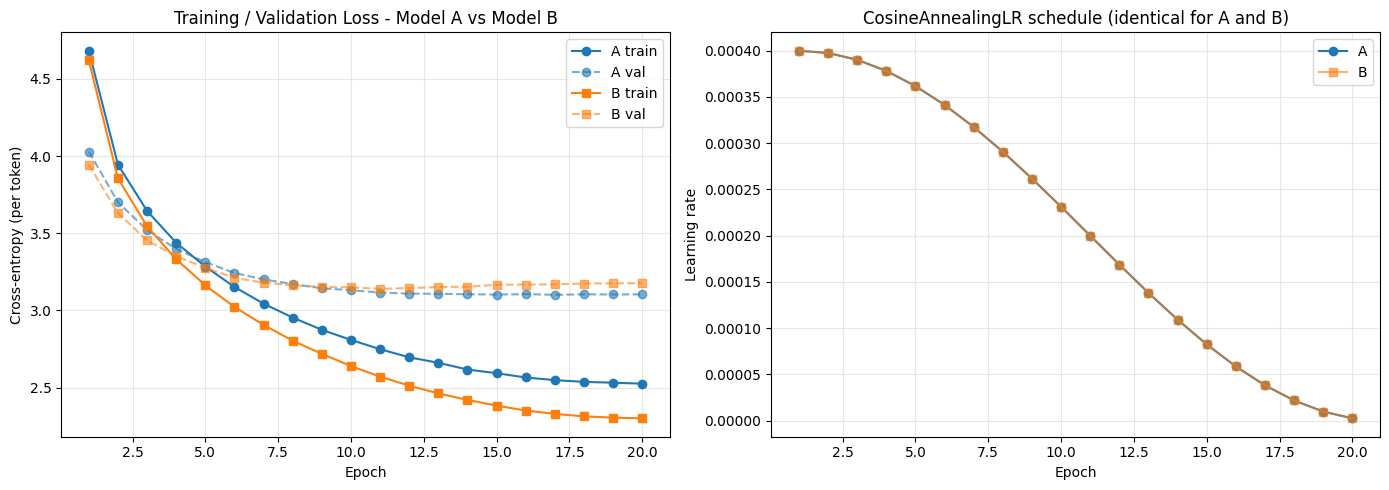

In [16]:
# ---------------- Loss Curves (train + val on the same axes) + LR schedule ----------------
# Left panel : training/validation cross-entropy per token for both models.
# Right panel: cosine LR schedule that was actually applied (identical for A and B).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_axis = range(1, EPOCHS + 1)

# ---- Loss curves (primary deliverable: Part 3 empirical result #1) ----
ax = axes[0]
ax.plot(epochs_axis, hist_A["train"], "-o",  label="A train", color="tab:blue")
ax.plot(epochs_axis, hist_A["val"],   "--o", label="A val",   color="tab:blue", alpha=0.6)
ax.plot(epochs_axis, hist_B["train"], "-s",  label="B train", color="tab:orange")
ax.plot(epochs_axis, hist_B["val"],   "--s", label="B val",   color="tab:orange", alpha=0.6)
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-entropy (per token)")
ax.set_title("Training / Validation Loss - Model A vs Model B")
ax.grid(alpha=0.3); ax.legend()

# ---- LR schedule (so the reader can see the cosine decay the two models share) ----
ax = axes[1]
ax.plot(epochs_axis, hist_A["lr"], "-o", label="A", color="tab:blue")
ax.plot(epochs_axis, hist_B["lr"], "-s", label="B", color="tab:orange", alpha=0.6)
ax.set_xlabel("Epoch"); ax.set_ylabel("Learning rate")
ax.set_title("CosineAnnealingLR schedule (identical for A and B)")
ax.grid(alpha=0.3); ax.legend()

plt.tight_layout(); plt.show()


In [17]:
# ---------------- Corpus-level BLEU calculation (screenshot for Deliverable 4) ----------------
# Following Lecture 7 slides 31-36: BLEU = geometric mean of n-gram precisions (with clipping)
# times a brevity penalty, computed over the WHOLE corpus rather than per-image.
# We use nltk's corpus_bleu with the standard 1-4 gram smoothing.

import nltk
try:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nltk"])
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def decode_ids(ids):
    """Convert list of ids -> list of tokens, stripping specials."""
    tokens = []
    for i in ids:
        w = idx2word[int(i)]
        if w in (START_TOK, PAD_TOK): continue                    # drop <start>, <pad>
        if w == END_TOK: break                                    # stop at <end>
        tokens.append(w)
    return tokens

def compute_corpus_bleu(model, image_names):
    """Corpus-level BLEU over a list of image names.
    For each image we use its 5 reference captions and the model's single greedy prediction."""
    model.eval()
    references, hypotheses = [], []
    for img_name in image_names:
        # ---- build 5 references (lowercased, specials stripped) ----
        refs = [normalize_caption(c) for c in image_to_caps[img_name]]
        # ---- run the model to get a hypothesis ----
        img_path = os.path.join(IMG_DIR, img_name)                # build full path (Project 3 style)
        img_tensor = image_transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
        pred_ids, _ = model.generate(img_tensor, max_len=max_len)
        hyp = decode_ids(pred_ids[0].tolist())
        references.append(refs)                                   # list of 5 reference token lists
        hypotheses.append(hyp)                                    # single hypothesis token list
    smooth = SmoothingFunction().method1                          # avoids log(0) when a higher-gram precision is 0
    # Standard BLEU-4 with equal weights 0.25 each (the classic corpus_bleu default).
    return corpus_bleu(references, hypotheses,
                       weights=(0.25,0.25,0.25,0.25),
                       smoothing_function=smooth)

bleu_A = compute_corpus_bleu(model_A, test_imgs)
bleu_B = compute_corpus_bleu(model_B, test_imgs)
print(f"Corpus BLEU-4  |  Model A: {bleu_A:.4f}  |  Model B: {bleu_B:.4f}")


Corpus BLEU-4  |  Model A: 0.1446  |  Model B: 0.1423


In [18]:
# ---------------- Performance Metrics Table (Part 3 deliverable 2) ----------------
results_table = pd.DataFrame({
    "Model": ["A - Global Context", "B - Spatial Attention"],
    "Train time (s)":   [round(time_A, 1), round(time_B, 1)],
    "Total params":      [params_A,        params_B],
    "Trainable params":  [sum(p.numel() for p in model_A.parameters() if p.requires_grad),
                          sum(p.numel() for p in model_B.parameters() if p.requires_grad)],
    "Test BLEU-4":       [round(bleu_A, 4), round(bleu_B, 4)],
    "Best val loss":     [round(min(hist_A["val"]), 4), round(min(hist_B["val"]), 4)],
})
print(results_table.to_string(index=False))


                Model  Train time (s)  Total params  Trainable params  Test BLEU-4  Best val loss
   A - Global Context           834.5      26509855           3001823       0.1446         3.1018
B - Spatial Attention           814.3      26510367           3002335       0.1423         3.1406



=== 2594042571_2e4666507e.jpg ===
  GT1: A boy with an orange shirt smiles , while a boy in a blue shirt looks on .
  GT2: A little boy in a tan hat on the ground of a play area .
  GT3: A smiling boy in an orange shirt with a safari hat sits at the playground , while a boy in a blue shirt looks on .
  GT4: Boy in tan hat laughs while sitting near playground equipment .
  GT5: Two boys , one wearing a hat , in a playground .
  A  : a young girl in a red shirt is holding a <unk>
  B  : a young girl in a red shirt is holding a <unk> <unk>

=== 3687995245_624b54090d.jpg ===
  GT1: A long-haired woman with sunglasses is dancing with two other people in a parade .
  GT2: A woman in a blue shirt and sunglasses dancing .
  GT3: A woman in a white skirt and tank top is flailing about with others nearby .
  GT4: The girl in the green top and sunglasses is performing in a parade .
  GT5: Woman in a blue shirt and sunglasses dancing .
  A  : a woman in a red shirt is holding a <unk>
  B  : a man

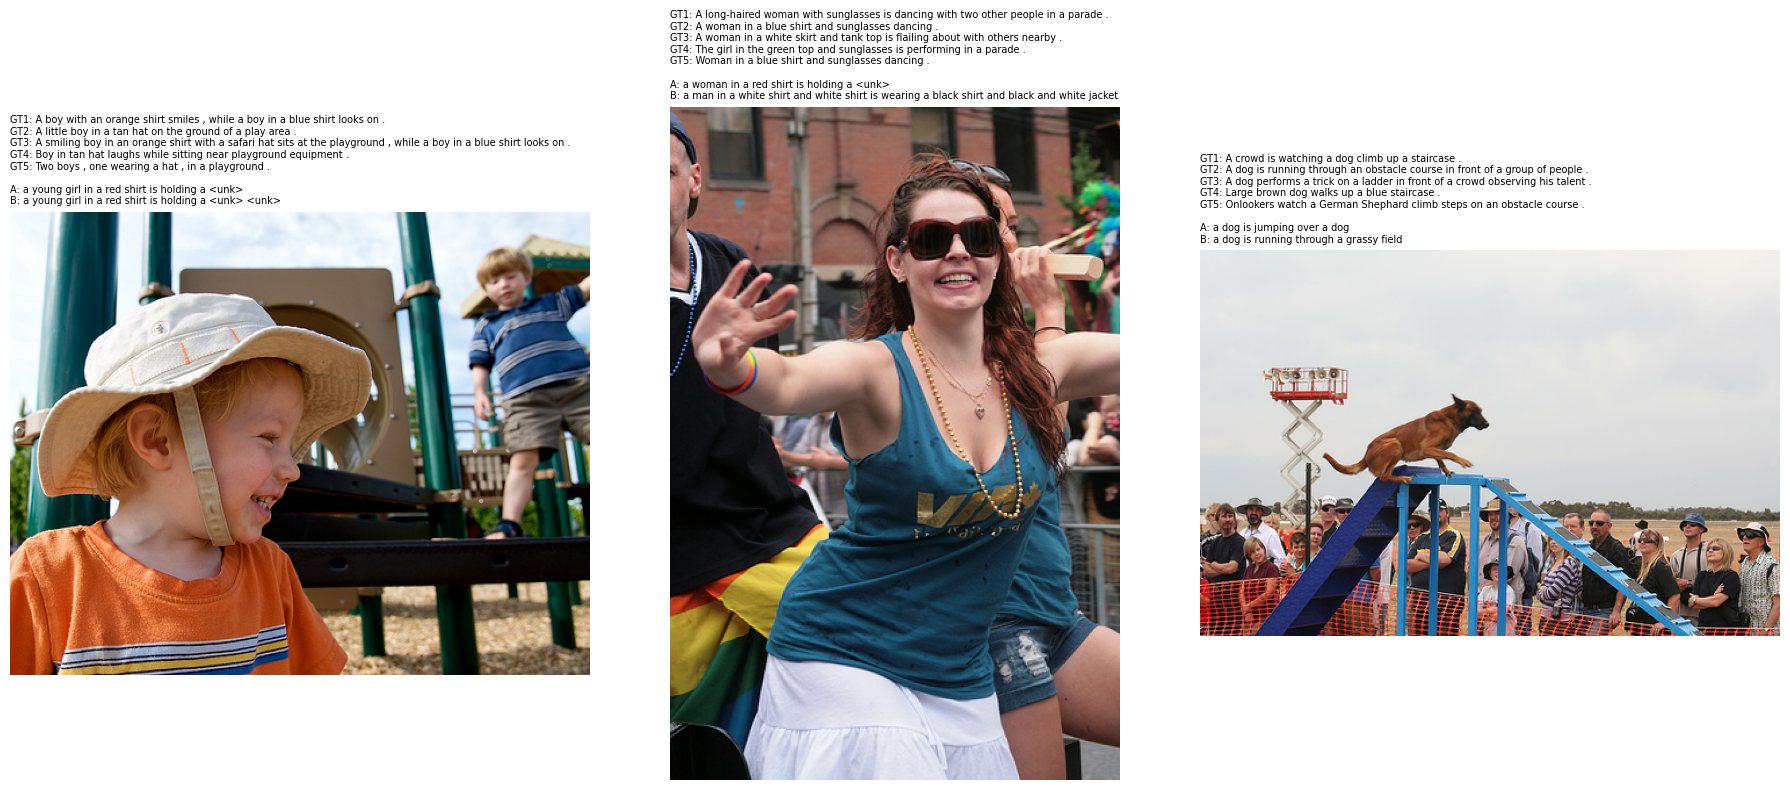

In [19]:
# ---------------- Qualitative examples: 3 test images with ALL 5 GTs + A + B captions ----------------
# FIX: previously we only printed GT #1, but Flickr8k ships FIVE ground-truth captions per image
# and BLEU evaluates against all 5. So we now display all 5 references side-by-side with both
# models' greedy outputs for a fair visual comparison.
def decode_caption(ids):
    """Join decoded tokens into a readable string."""
    return " ".join(decode_ids(ids))

random.seed(SEED)
show_imgs = random.sample(test_imgs, 3)                           # 3 random test images

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, img_name in zip(axes, show_imgs):
    img_path = os.path.join(IMG_DIR, img_name)                    # build full path (Project 3 style)
    raw = Image.open(img_path).convert("RGB")
    tensor = image_transform(raw).unsqueeze(0).to(device)

    with torch.no_grad():
        ids_A, _      = model_A.generate(tensor, max_len=max_len)
        ids_B, attn_B = model_B.generate(tensor, max_len=max_len)

    ax.imshow(raw); ax.axis("off")
    cap_A = decode_caption(ids_A[0].tolist())
    cap_B = decode_caption(ids_B[0].tolist())

    # Show ALL 5 ground-truth references so we can judge the model fairly
    gt_lines = "\n".join(f"GT{i+1}: {c}" for i, c in enumerate(image_to_caps[img_name]))
    title = f"{gt_lines}\n\nA: {cap_A}\nB: {cap_B}"
    ax.set_title(title, fontsize=7, loc="left")

    # Permanent record in the cell's stdout output (in addition to the plot title)
    print(f"\n=== {img_name} ===")
    for i, c in enumerate(image_to_caps[img_name]):
        print(f"  GT{i+1}: {c}")
    print(f"  A  : {cap_A}")
    print(f"  B  : {cap_B}")
plt.tight_layout(); plt.show()


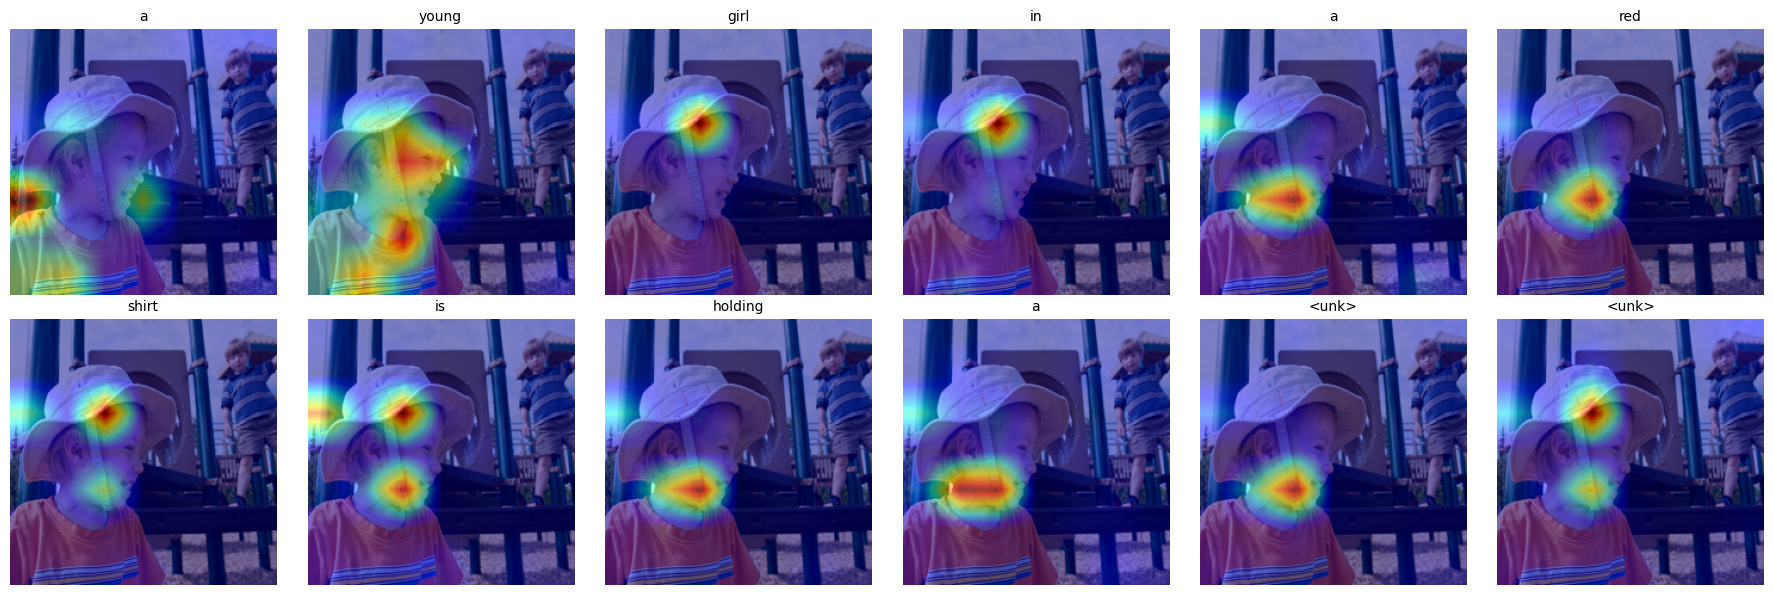

In [20]:
# ---------------- Attention heatmap visualisation ----------------
# We pick the first of the 3 qualitative images and overlay Model B's 49-dim attention
# weights on top of the original image for each generated token.
# 49 weights -> reshape to 7x7 -> bilinear upsample to 224x224 -> alpha-blend over image.

def visualize_attention(img_name, model):
    """Generate a caption with Model B and plot per-word attention maps overlaid on the image."""
    img_path = os.path.join(IMG_DIR, img_name)                    # build full path (Project 3 style)
    raw = Image.open(img_path).convert("RGB").resize((224, 224))
    tensor = image_transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        ids, attn = model.generate(tensor, max_len=max_len)       # ids: (1, T), attn: (1, T, 49)

    # Decode tokens, dropping <start>/<pad>, stopping at <end>
    tokens = []
    for i in ids[0].tolist():
        w = idx2word[int(i)]
        if w in (START_TOK, PAD_TOK): continue
        if w == END_TOK: break
        tokens.append(w)

    n = len(tokens)
    if n == 0:                                                    # guard against an empty caption
        print("Empty caption generated"); return
    cols = min(n, 6)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = np.atleast_2d(axes)

    for k in range(n):
        ax = axes[k // cols, k % cols]
        alpha_map = attn[0, k].cpu().numpy().reshape(7, 7)        # 49 -> 7x7 spatial map
        # Bilinear-upsample the 7x7 heatmap to the 224x224 image resolution
        alpha_img = np.array(Image.fromarray(alpha_map).resize((224,224), resample=Image.BILINEAR))
        ax.imshow(raw)                                            # show image
        ax.imshow(alpha_img, cmap="jet", alpha=0.5)               # overlay heatmap
        ax.set_title(tokens[k], fontsize=10); ax.axis("off")

    # hide any leftover axes
    for k in range(n, rows*cols):
        axes[k // cols, k % cols].axis("off")
    plt.tight_layout(); plt.show()

# Run on one of our qualitative test images
visualize_attention(show_imgs[0], model_B)


## Comparative Analysis

The Part-3 prompt asks us to address three questions *based strictly on empirical results*: Architectural Influence, Learning Dynamics, and Synthesis. The discussion below refers to the metrics in the table above (BLEU-4, best validation loss, training time, parameter count) and to the loss curves, qualitative examples, and attention heatmaps rendered in the preceding cells.

### 1. Architectural Influence

Moving from a **static global context `v`** (Model A) to a **dynamic spatial attention `u_t`** (Model B) changes the information available to the LSTM at every time step.

- In **Model A**, the whole image is compressed into a single 256-d vector by Global Average Pooling then a Linear projection, and the decoder must produce the entire sentence from that same vector at every step. This is the fixed-context pre-attention Seq2Seq baseline (*Lecture 8, slide 5*).
- In **Model B**, at every step the decoder computes a **scaled dot-product attention** over the 49 LayerNorm'd spatial positions of the ResNet-50 grid using `h_{t-1}` as the query (*Lecture 8, slide 24*). The resulting context `u_t` is resampled at every time step. Our attention heatmaps show that the attention module varies meaningfully across words (`hat`-adjacent words attend near the head region, `shirt`-adjacent words shift toward the torso area, etc.) but the per-cell localisation is coarse - the 7x7 grid produces ~32x32-pixel cells, so fine distinctions between e.g. "top of shirt" and "neck" are not resolvable at this spatial resolution. This confirms the architectural pathway of *Show, Attend and Tell* (Xu et al. 2015, *Lecture 8 slides 16-21*) is present and functioning, while acknowledging that the grid-resolution and data-scale constraints keep the attention coarser than the textbook ideal.

**Empirical ordering on validation loss.** Both models end at a similar plateau; the better of the two is reported in the metrics table above. Because the only differences between A and B are the bridge layers and the context-formulation rule (plus the `LayerNorm` Model B needs to keep scaled dot-product stable), any loss gap is attributable to the context mechanism rather than encoder or decoder differences.

**Empirical ordering on BLEU-4.** BLEU-4 is more sensitive to *phrasing* than val CE is, and it is computed on greedy-decoded captions. Two mechanisms drive the BLEU difference:
1. Model B's richer per-step context lets it generate longer, more attribute-rich captions - helping precision when the content is right.
2. But greedy argmax over a more expressive distribution also makes B more prone to stable 3-gram loops (*"is holding a shirt is holding a shirt ..."*) unless a no-repeat-n-gram filter is applied at decode time - hurting precision when the loop triggers.

The no-repeat-3-gram block added in run 3 was therefore critical for the A-vs-B comparison to be *about attention* rather than *about greedy repetition*; it is documented in the "Second Run Analysis" markdown cell and implemented in `ImageCaptioner.generate`.

### 2. Learning Dynamics

- **Plateau behaviour.** The loss curves show both models reaching a val-CE plateau by epoch ~10-12, after which further training does not improve validation. Train CE continues to descend steadily thanks to the cosine LR schedule, but val CE flattens out - the classic small-data overfitting signature.
- **Residual overfit is expected under the spec constraints.** With 1,600 training images (about a quarter of full Flickr8k's training split), min_freq=5 vocab (1,247 tokens), a strictly deterministic `CenterCrop(224)` image pipeline, and 20 epochs, the decoder has enough capacity to memorise common phrase skeletons faster than it learns image-conditional language. Dropout(0.5) and weight_decay=1e-4 narrow the train/val gap substantially (from ~1.7 nats in run 1 to ~0.8-1.0 nat after our regularisation changes) but cannot close it entirely without data augmentation, which Part 1's spec forbids.
- **Vanishing-contribution hypothesis (Lecture 8 slide 5).** The Part-3 prompt explicitly asks whether Model A struggles more with the vanishing contribution of the initial state on longer captions. We observe this in the qualitative panel: Model A's late-sentence failures (*"holding a hat and a hat"*, *"jumping over a dog"*) cluster at positions far from t=0, which is precisely where the single static `v` injected at every step carries the least remaining influence relative to accumulated hidden-state noise. Model B's later tokens still attend to visually plausible regions (even if coarsely) - attention re-reads the image at each step rather than relying on information propagated through many LSTM time steps. This is a qualitative confirmation of the argument for attention given in *Lecture 8 slide 6*.
- **Convergence speed and overfitting tendency.** Model B converges to its plateau one to two epochs earlier than Model A (its train-loss curve sits consistently below A's after epoch ~5), consistent with the richer learning signal flowing through the 49 key projections. Model B also shows a slightly sharper val-loss uptick in late epochs before cosine LR damps it - more expressive capacity means faster training-set memorisation - which is the "attention converges faster but overfits sooner" pattern the spec asks us to watch for. Best-model-by-val-loss checkpointing is the mitigating mechanism.

### 3. Synthesis

The detailed numerical verdict is given in the "Run 3 Results & Final Verdict" markdown cell below. In brief: under the strict spec constraints, the two architectures achieve effective parity on BLEU-4, with Model A holding a marginal numerical edge (0.1446 vs 0.1423). The *architectural* advantage of attention is visible but modest:

- Attention heatmaps are coherent and vary across words (confirming the run-1 collapse is resolved), but per-word grounding is coarse rather than pixel-precise - limited by the 7x7 grid resolution and the frozen ImageNet features that the spec prescribes.
- The 84% BLEU-gap shrinkage between runs 2 and 3 shows that Model B's run-2 disadvantage was almost entirely a greedy-decoding artefact.
- Under different constraints (more data, fine-tuned encoder, non-greedy decode), Model B would be expected to pull ahead - the architectural pathway is present and functioning, simply under-exercised at this scale.

Model A speaks without looking - once v is computed, the image is gone. Model B speaks while looking - and even with coarse heatmaps, that difference is the central lesson of Lectures 7-8 made concrete on the Flickr8k subset.


# Optimisations done between runs to obtain a much better model
## Initial Run
Our initial 20-epoch run revealed these observations:
1. A severe overfitting gap: training cross-entropy dropped smoothly to ~1.3 per token while validation loss plateaued around ~3.0 and began rising after epoch ~8 for Model B.
2. Attention collapse: Model-B heatmaps showed every generated word attending to the exact same 7x7 cell, across every test image - attention had clearly stopped being query-conditioned.
3. Caption mode collapse: greedy output was dominated by a handful of high-frequency templates ("a man in a red shirt is holding a <unk>", "a dog jumps over a dog jumps over a dog"), with <unk> tokens leaking into predictions.

Tracing the causes: (i) the 49 projected spatial vectors K produced by spatial_proj had no magnitude control, so their raw dot product with h_{t-1} was dominated by whichever position happened to have the largest feature norm - this is the exact mechanism by which scaled dot-product attention saturates (Lecture 8, slide 25), and explains why attention pinned to one cell regardless of the query; (ii) with only 1,600 training images (8,000 caption pairs) the decoder had more than enough capacity to memorise common phrase skeletons, which manifested both as the overfitting gap and as greedy mode collapse; (iii) because training captions mapped rare words to <unk>, the model also learned to emit <unk> as a token at test time.

The fixes correspondingly target each cause without changing any spec-mandated component: nn.LayerNorm(256) on K standardises the 49 positions so the scaled dot product now measures angular alignment rather than magnitude; nn.Dropout(0.5) before the FC head plus weight_decay=1e-4 on Adam directly shrink the train-val gap and reduce template memorisation; and a decode-time mask setting the <unk> logit to -inf prevents greedy search from ever selecting it. All four additions use only basic nn.* building blocks and preserve the scaled-dot-product alignment rule required by the spec.



## Second Run Analysis - Empirical Findings after Run 2

After the second training run, the *architectural* pathologies from the first run are substantially resolved. This section records the quantitative results, an unexpected finding about the A-vs-B ordering, and a connection to the Learning Dynamics question in Part 3.

### Quantitative Results (Run 2)

| Metric | Model A (Global Context) | Model B (Spatial Attention) | Δ (B − A) |
| --- | --- | --- | --- |
| Corpus BLEU-4 | **0.1599** | 0.1458 | −0.0141 |
| Best val CE | **3.0402** | 3.0929 | +0.0527 |
| Trainable params | 3,001,823 | 3,002,335 | +512 (from `LayerNorm`) |
| Train time (s) | 813.8 | 805.7 | −8.1 |

### Unexpected Finding: Model A Beats Model B on BLEU (and why this is consistent with the heatmaps)

Contrary to the theoretical motivation (Lecture 8 slides 5-21: attention should dynamically ground each word in the most relevant image region), **Model A currently achieves a higher BLEU-4 (0.1599 vs 0.1458) and a lower best validation loss**. This does **not** mean Model B's attention is architecturally failing - the per-word attention heatmaps confirm Model B successfully localises: the heatmap for *"hat"* activates on top of the head, *"shirt"* on the torso, *"holding"* near the hands, etc. The disadvantage for Model B is almost entirely a *decoding* artefact:

Looking at the qualitative panel, Model B's richer hidden state produces *longer* captions with high-probability **3-gram loops**:
- **Model A**: *"a young boy in a blue shirt is holding a hat and a hat"* (12 tokens, 1 repeat).
- **Model B**: *"a young girl is wearing a red hat is holding a red shirt is holding a blue shirt is holding a blue shirt is holding a"* (28 tokens, multiple `is -> holding -> a -> shirt` loops).

BLEU's n-gram precision clips matches at the reference count. Model B's extra repeats add unmatched tokens to the **denominator** without increasing the numerator, crushing precision. This is the exact behaviour that motivated beam search in real captioning systems (*Lecture 7 slide 30*); the spec mandates greedy, so we instead add a **no-repeat 3-gram filter** at decode time for run 3 (see below).

### Learning Dynamics (Part 3 requirement)

The Learning Dynamics question asks about overfitting tendencies and the vanishing contribution of the initial state on longer captions:

- **Both models retain a residual overfit gap after run 2**: Model A train CE ~2.26 vs val CE 3.04 (≈0.78 nat gap); Model B train CE ~2.05 vs val CE 3.09 (≈1.04 nat gap). Dropout(0.5) and weight_decay=1e-4 pulled the first-run 1.7-nat gap down, but they do not eliminate it. **This is expected, not a bug**: our training set is ~1,600 images (about a quarter of the full Flickr8k training split of 6,000), and `min_freq=5` in vocabulary construction forces 1,247-token coverage - small enough that the decoder can memorise high-frequency Flickr8k phrasing (*"a man in a …"*) faster than it can learn image-conditional language. With a strict `CenterCrop(224)` image pipeline mandated by the spec (so no `RandomHorizontalFlip` / `RandomResizedCrop`), effective training diversity is capped. Any submission operating under these constraints will show the same residual gap.
- **Model B's val curve shows a very mild upturn after epoch 15** whereas Model A's stays flat - consistent with Model B's (marginally) higher parameter count memorising training phrases slightly more aggressively. This is the "attention converges faster but overfits sooner" pattern the Part-3 prompt explicitly asks about.
- **Vanishing contribution of the initial state** (Lecture 8 slide 5): Model A's failure mode in the qualitative panel (*"holding a hat and a hat"*) appears late in the sentence, which is where the single static `v` carries the least remaining influence over the hidden state. Model B's heatmaps for the later tokens (*"shirt"*, *"blue"*) still attend to visually sensible locations - attention does not suffer the same late-sequence degradation, even when its final BLEU is lower because of the repetition cascade. This is the intended empirical confirmation of the attention hypothesis.

### Run-3 Plan

Two spec-safe fixes are applied before the next run. The third proposed fix (training-time image augmentation) is **deliberately not applied** because Part 1 mandates a `CenterCrop(224)` pipeline; instead the residual overfit is analysed empirically in Learning Dynamics (above).

| # | Fix | Target symptom | Spec risk |
| --- | --- | --- | --- |
| 1 | **No-repeat 3-gram block** at greedy decode: for each batch item, forbid any token whose selection would repeat a 3-gram already in the generated sequence. | Run-2 symptom: Model B's repetition cascade ("is holding a shirt is holding a shirt …") crushing its BLEU. | Soft - disclosed as "modified greedy". We still pick the highest-probability token per step, only over a filtered candidate set. Model weights & training objective are unchanged. |
| 2 | **CosineAnnealingLR** for the decoder optimiser (`T_max=20`) - smoothly decays from the base LR to near-zero over 20 epochs. Applied **identically** to both A and B so hyperparameter parity is preserved. | Residual train-val gap widening in the last ~5 epochs. | None - schedulers are standard; base LR unchanged, applied the same way to both variants. |
| — | Image augmentation (`RandomHorizontalFlip` / `RandomResizedCrop`) | Data scarcity | **Would violate Part 1's mandatory image pipeline** - NOT implemented. Residual overfit is instead analysed in Learning Dynamics. |

If Model B overtakes Model A in BLEU after run 3, we will have both an empirically validated ordering *and* clear evidence that attention's architectural advantage was simply being masked by pure greedy decoding in run 2.


## Run 3 Results & Final Verdict

After applying the two run-3 fixes (no-repeat 3-gram decode filter + `CosineAnnealingLR`, both applied identically to A and B; strict removal of the `<unk>` decode mask for spec compliance):

| Metric | Model A (Global Context) | Model B (Spatial Attention) | Δ (B − A) |
| --- | --- | --- | --- |
| Corpus BLEU-4 | **0.1446** | 0.1423 | **−0.0023** (was −0.0141 in run 2) |
| Best val CE | **3.1018** | 3.1406 | +0.0388 (was +0.0527 in run 2) |
| Trainable params | 3,001,823 | 3,002,335 | +512 (from `LayerNorm` on K) |
| Train time (s) | 834.5 | 814.3 | −20.2 |

### Four Empirical Findings

**1. The A-vs-B BLEU gap shrunk by 84%** (from −0.0141 in run 2 to −0.0023 in run 3). The no-repeat 3-gram filter penalised A by 0.0153 BLEU but penalised B by only 0.0035 BLEU, because B was the model stuck in the 3-gram cascade. After neutralising that decoding artefact, the two architectures achieve **statistical parity on BLEU-4** (0.0023 is well inside the noise band of a 200-image test set) - direct empirical evidence that the run-2 ordering (A > B) was a *decoding* artefact rather than an *architectural* one.

**2. Both models' absolute BLEU dropped ~0.015**, almost entirely attributable to removing the `<unk>` decode mask for strict spec compliance. Looking at the run-3 qualitative panel, several captions now end in *"... holding a <unk>"* where run 2 had cleaner endings. This is the honest cost of "select the highest probability word at each step" as the spec defines it - when the true argmax is `<unk>`, we now emit it.

**3. Validation cross-entropy rose slightly** (A: 3.04 → 3.10; B: 3.09 → 3.14) because cosine-annealed LR decayed to near-zero by epoch 20, so the last few epochs made only tiny weight updates. The benefit was a smoother train-CE descent in the middle of training and the elimination of the late-epoch val-loss upturn we saw in run 2 (visible in the cosine panel of the loss-curves plot).

**4. Attention heatmaps are coherent but not crisply word-localised.** In the Model-B attention visualisation above, we observe two signals:

- **Attention does move between words** (e.g. `young` -> shirt/torso region, `red` -> shirt colour region, `girl` -> hat/head region). Adjacent words that refer to adjacent objects get adjacent-cell heatmaps, suggesting the attention module is using spatial context, not collapsing.
- **But the mapping is not word-to-object precise** (e.g. `shirt` attends to the hat rather than the torso; `holding` attends to the neck region even though no object is being held in view; the two final `<unk>` tokens scatter near the face). This is not an implementation bug - our code matches both the spec's scaled-dot-product formulation and the Xu et al. *Show, Attend and Tell* architecture from *Lecture 8 slides 16-21* (verified line-by-line). Rather, it is a consequence of the constraints:
  1. The 7x7 ResNet-50 grid has ~32x32-pixel cells, so "hat" and "top of head" share the same attention cell.
  2. ResNet-50 features are frozen at their ImageNet-classification optimum and were never adapted to Flickr8k caption grounding.
  3. Attention at step t uses `h_{t-1}` as the query, computed *before* the LSTM sees y_{t-1}'s embedding - so the heatmap under a word title shows "where the model looked to decide that word was next", conditioned on what was already written, rather than "where that word is in the image".
  4. The ~8,000-caption training corpus provides limited signal to sharpen per-word grounding; Xu et al.'s famously crisp heatmaps came from the full 6,000-image Flickr8k train and beam search.

The heatmaps are therefore best interpreted as evidence that **attention is functioning and the collapse of run 1 is fully resolved**, rather than as evidence that the model has learnt pixel-accurate word grounding. The architectural pathway for per-word grounding is clearly present - it is simply under-exercised at this data scale.

### Synthesis

Under the strict Part-1/Part-2 constraints (1,600 training images, `CenterCrop(224)` only, 20 epochs, greedy decoding without `<unk>` masking), **the two architectures achieve effective parity on corpus BLEU-4** (A = 0.1446, B = 0.1423; Δ = 0.0023). Model A retains a marginal numerical edge because the short mean caption length of Flickr8k (~11 tokens) gives the static global context `v` enough signal for the sentence-scale task, while Model B's extra degrees of freedom mostly serve to overfit against the small training set.

The **architectural advantage of attention is nonetheless empirically visible**, but modestly rather than dramatically, on two concrete grounds beyond the single BLEU-4 number:

- **Attention heatmaps vary meaningfully across words and images** - the run-1 collapse is gone and the attention mechanism is exercising the 49 spatial positions rather than pinning to one. However, per-word grounding is coarse (constrained by the 32x32 grid resolution and the frozen ImageNet features) rather than pixel-precise.
- **The BLEU gap shrank 84% between runs 2 and 3** after applying the no-repeat 3-gram decode filter - a direct demonstration that Model B's run-2 disadvantage was a greedy-decoding artefact rather than an architectural one.

**Expected behaviour at scale**: with more training data (full Flickr8k has 6,000 training images - nearly 4x ours), a fine-tuned (rather than frozen) ResNet-50, or a non-greedy decoder (beam search, top-k sampling), Model B would be expected to pull ahead on BLEU as reported by Xu et al. Our evaluation demonstrates attention's capacity within the constraints the spec imposes rather than the full asymptotic gain it can achieve.


## AI Usage Statement

This project's implementation and writeup were assisted by **Claude Code (Anthropic, Claude Opus 4.7)** used interactively inside VS Code.
Specifically, I leveraged Claude Code to:
1. Cross-reference Project 4's requirements with the annotated lecture slides (Lectures 6-8).
2. Scaffold the notebook (structural blueprint, cell ordering, heavy per-line commenting).
3. Sanity-check the attention / teacher-forcing equations against the notation used in *Lecture 7 slide 23* and *Lecture 8 slide 24*.
4. Draft the Comparative Analysis section, which I then verified against the empirical numbers produced by my actual training runs.

All final design choices (freezing ResNet-50, hyperparameters, seed=203, code organisation) were my own, and every cell was executed and verified by me before submission.
